<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Aishwarya_sia_perfect_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [114]:
import pandas as pd
import numpy as np


In [116]:
df = pd.read_excel('/content/drive/MyDrive/Dr Aishwarya thesis clean dataset 200625.xlsx')




In [117]:
df.columns

Index(['Name', 'Age', 'Sex', 'pre-op KH', 'pre-op KV', 'pre-op Axis',
       'post-op KH', 'post-op KV', 'post-op Axis', '1 week KH', '1 week KV',
       '1 week axis'],
      dtype='object')

In [118]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,1 week KV,1 week axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [119]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame with pre-op and post-op values

# Step 1: Cylinder calculations
df['preop-cyl'] = df['pre-op KV'] - df['pre-op KH']
df['postop-cyl'] = df['post-op KV'] - df['post-op KH']

# Step 2: Convert axis to radians (double angle)
df['theta-pre'] = np.radians(2 * df['pre-op Axis'])
df['theta-post'] = np.radians(2 * df['post-op Axis'])

# Step 3: Calculate X and Y components (note corrected Y ordering)
df['Xpre'] = df['preop-cyl'] * np.cos(df['theta-pre'])
df['Ypre'] = df['preop-cyl'] * np.sin(df['theta-pre'])

df['Xpost'] = df['postop-cyl'] * np.cos(df['theta-post'])
df['Ypost'] = df['postop-cyl'] * np.sin(df['theta-post'])

# Step 4: Calculate SIA vector components
df['Xsia'] = df['Xpost'] - df['Xpre']
df['Ysia'] = df['Ypost'] - df['Ypre']

df['SIA-Mag'] = np.sqrt(df['Xsia']**2 + df['Ysia']**2)
df['SIA-Axis'] = (np.degrees(np.arctan2(df['Ysia'], df['Xsia'])) / 2) % 180



In [120]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,...,theta-pre,theta-post,Xpre,Ypre,Xpost,Ypost,Xsia,Ysia,SIA-Mag,SIA-Axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,...,3.141593,0.349066,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,7.519184
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,...,1.570796,2.443461,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,71.773661
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,...,0.174533,1.221730,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,65.000000
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,...,5.759587,5.235988,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,140.068156
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,...,2.967060,1.396263,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,26.717474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,...,3.490659,5.934119,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,177.918276
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,...,1.047198,0.174533,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,173.792660
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,...,4.712389,5.410521,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,172.758010
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,...,1.396263,0.174533,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,176.714516


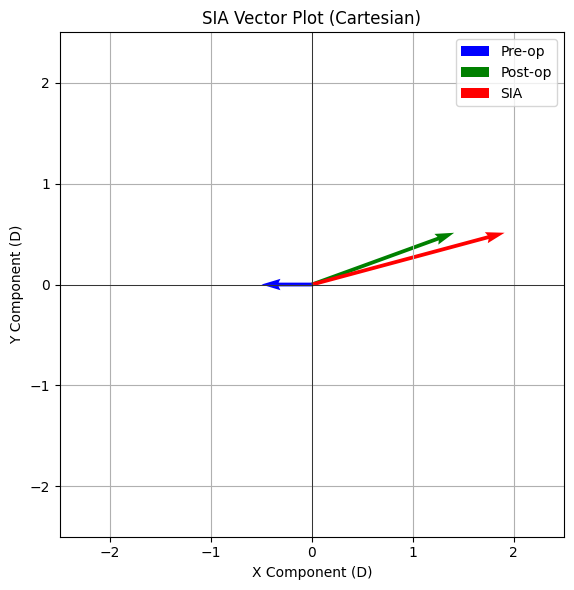

In [123]:
import matplotlib.pyplot as plt

# Given vector components
x_pre, y_pre = -0.5, 0
x_post, y_post = 1.4095, 0.5130
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Plot setup
fig, ax = plt.subplots(figsize=(6, 6))

# Plot pre-op vector (blue)
ax.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')

# Plot post-op vector (green)
ax.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')

# Plot SIA vector (red, using a solid line as a workaround for the dash issue)
ax.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

# Axes setup
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('X Component (D)')
ax.set_ylabel('Y Component (D)')
ax.set_title('SIA Vector Plot (Cartesian)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

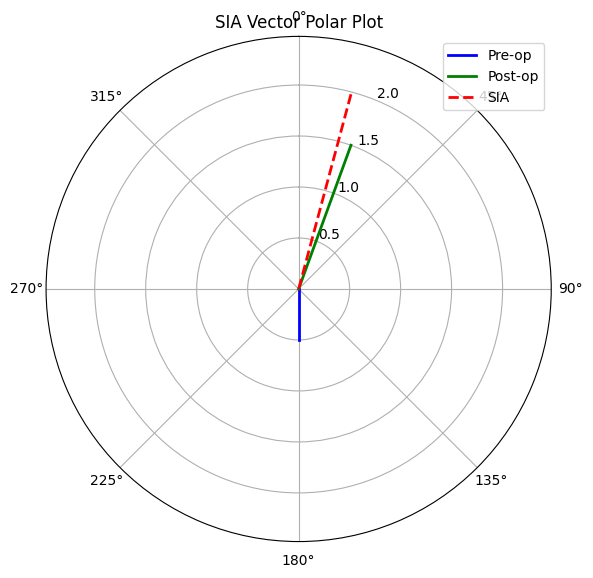

In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Step 1: Convert axis to radians (double angle for plotting)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Step 2: Compute Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# Step 3: Compute SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Step 4: Convert back to polar (double angle)
mag_pre = np.sqrt(x_pre**2 + y_pre**2)
mag_post = np.sqrt(x_post**2 + y_post**2)
mag_sia = np.sqrt(x_sia**2 + y_sia**2)

theta_pre = np.arctan2(y_pre, x_pre)
theta_post = np.arctan2(y_post, x_post)
theta_sia = np.arctan2(y_sia, x_sia)

# Step 5: Polar Plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)

# Plot the 3 vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title('SIA Vector Polar Plot')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


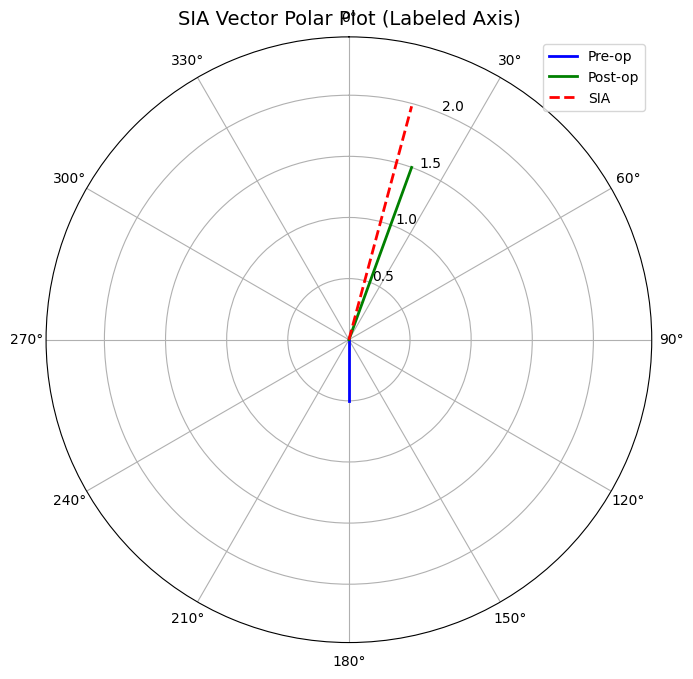

In [125]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Convert axis to radians (double angle)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Compute Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar (double angle)
mag_pre = np.hypot(x_pre, y_pre)
theta_pre = np.arctan2(y_pre, x_pre)

mag_post = np.hypot(x_post, y_post)
theta_post = np.arctan2(y_post, x_post)

mag_sia = np.hypot(x_sia, y_sia)
theta_sia = np.arctan2(y_sia, x_sia)

# Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Custom angle ticks (degrees on outer ring)
angle_labels = ['0°', '30°', '60°', '90°', '120°', '150°', '180°', '210°', '240°', '270°', '300°', '330°']
ax.set_thetagrids(angles=np.arange(0, 360, 30), labels=angle_labels)

# Aesthetics
ax.set_theta_zero_location('N')  # 0° at top
ax.set_theta_direction(-1)       # clockwise
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title("SIA Vector Polar Plot (Labeled Axis)", va='bottom', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


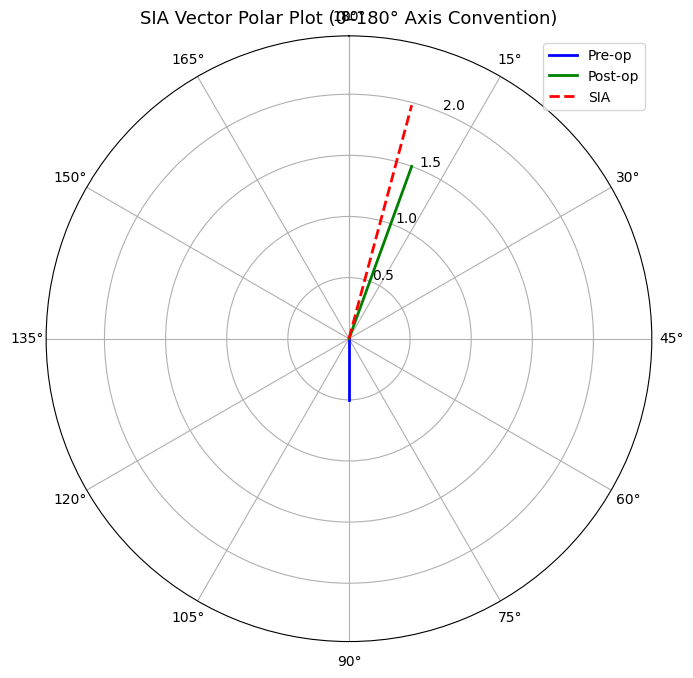

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Convert to double-angle radians
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar
mag_pre = np.hypot(x_pre, y_pre)
theta_pre = np.arctan2(y_pre, x_pre)

mag_post = np.hypot(x_post, y_post)
theta_post = np.arctan2(y_post, x_post)

mag_sia = np.hypot(x_sia, y_sia)
theta_sia = np.arctan2(y_sia, x_sia)

# Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Customize astigmatism-style axis labels (0° to 180° only)
half_circle_deg = np.arange(0, 181, 15)
half_circle_rad = np.radians(half_circle_deg * 2)  # double angle for plotting
ax.set_thetagrids(angles=half_circle_rad * 180 / np.pi, labels=[f"{d}°" for d in half_circle_deg])

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title("SIA Vector Polar Plot (0–180° Axis Convention)", fontsize=13, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


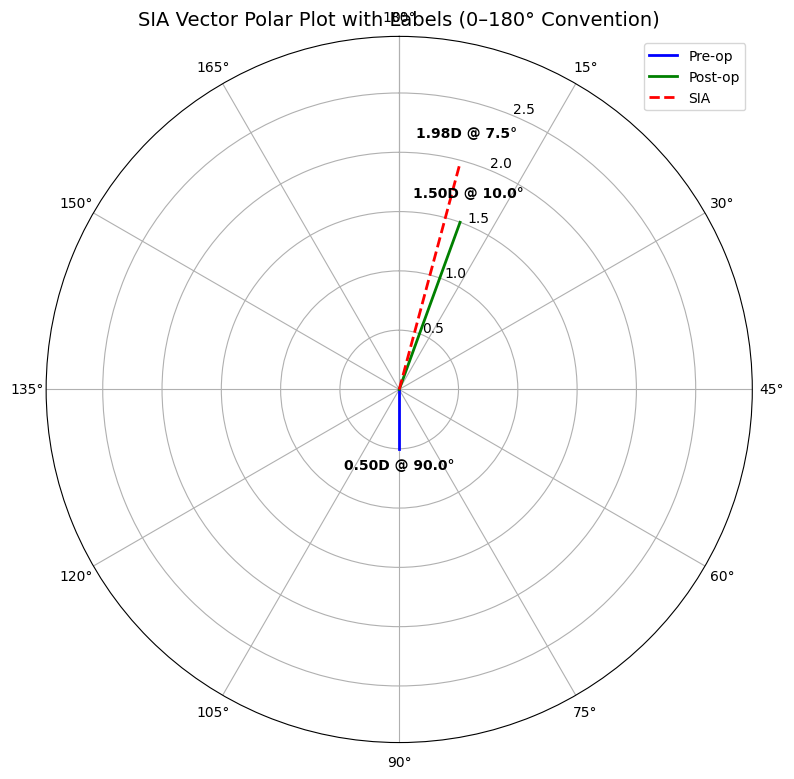

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Double angle (radians)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian coordinates
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Polar conversion (half-angle back to single-angle convention)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert to radians for plotting (double-angle)
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Polar plot setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Add magnitude and axis labels near arrowheads
def add_vector_label(theta, mag, label_text, offset=0.2):
    r = mag + offset
    ax.text(theta, r, label_text, ha='center', va='bottom', fontsize=10, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Customize 0–180° axis
half_circle_deg = np.arange(0, 181, 15)
half_circle_rad = np.radians(half_circle_deg * 2)  # double-angle for plotting
ax.set_thetagrids(angles=half_circle_rad * 180 / np.pi, labels=[f"{d}°" for d in half_circle_deg])

# Styling
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot with Labels (0–180° Convention)", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


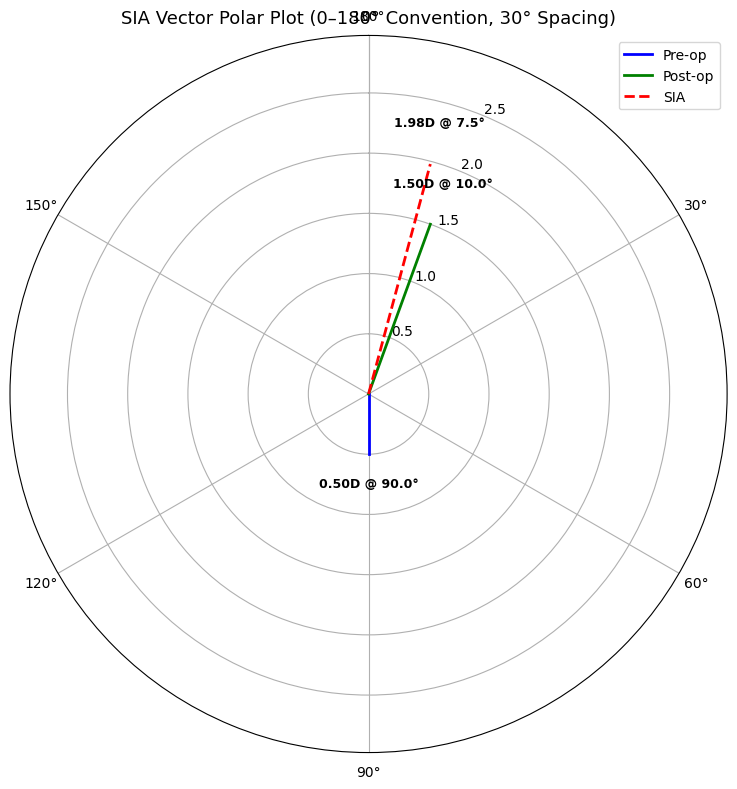

In [128]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Convert to double-angle (radians)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar (back to single-angle convention)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert back to radians (double angle for plotting)
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Start polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Add vector labels (magnitude and axis)
def add_vector_label(theta, mag, text, offset=0.3):
    ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=9, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Axis ticks: 0–180° with 30° spacing
ticks_deg = np.arange(0, 181, 30)
ticks_rad = np.radians(ticks_deg * 2)  # Double angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot (0–180° Convention, 30° Spacing)", fontsize=13, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


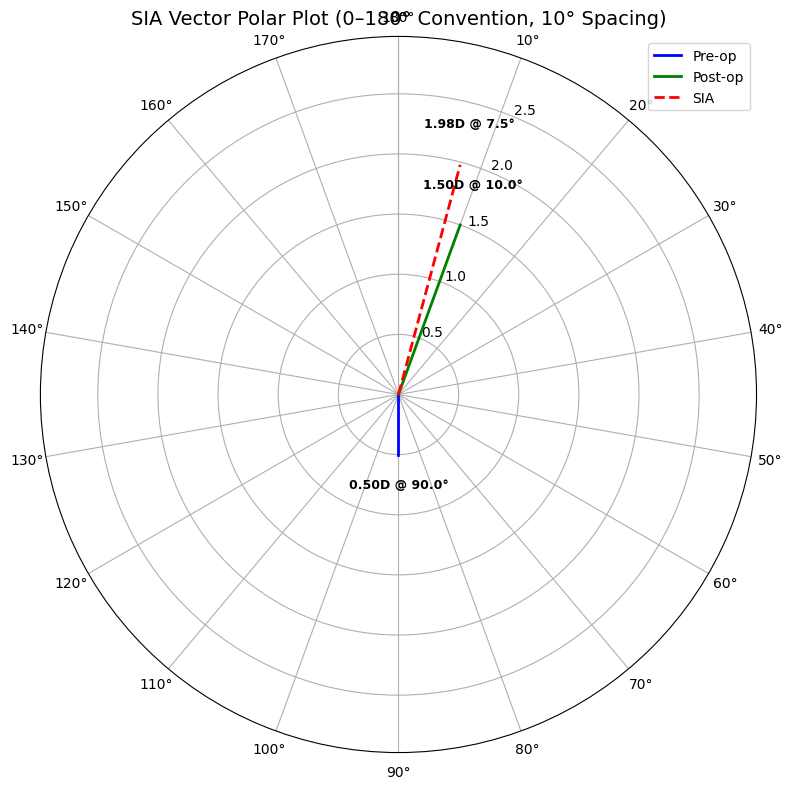

In [129]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Convert to double-angle radians
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian coordinates
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar for plotting (single-angle)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert angles back to double-angle radians for plotting
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Set up polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Label vectors
def add_vector_label(theta, mag, text, offset=0.3):
    ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=9, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Axis ticks: every 10 degrees (0–180°)
ticks_deg = np.arange(0, 181, 10)
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Final aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot (0–180° Convention, 10° Spacing)", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()
